In [1]:
# 로깅 설정
import logging
import asyncio
import aiohttp
import ssl
import certifi
import json
import pandas as pd
import numpy as np
import time
import random
import seaborn as sns
import sqlite3
import mysql.connector
from urllib.request import urlopen
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# warnings.filterwarnings("ignore")

#### 1. 상장기업 매출액 API 수신

In [2]:
# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [3]:
# def get_adata_annual(adata, data_name):
#     data = adata.pivot_table(index='date', columns='ticker', values=data_name).astype('float')
#     data = data.ffill(limit=11)  # Replace fillna(method='ffill') with ffill()
#     data = data.loc[[x for x in data.index if x.month == 6]].reindex(data.index).ffill(limit=11).dropna(how='all')
#
#     return data
#
# def get_last_quarter_end():
#     # 현재 날짜 가져오기
#     today = date.today()
#
#     # 분기 마지막 월 정의 (Q1: 3월, Q2: 6월, Q3: 9월, Q4: 12월)
#     quarter_months = [3, 6, 9, 12]
#
#     # 현재 분기의 시작 월 찾기
#     for m in quarter_months:
#         if today.month <= m:
#             last_quarter_month = quarter_months[quarter_months.index(m) - 1]
#             break
#     else:
#         last_quarter_month = 12  # 현재가 1월이라면, 작년 12월이 마지막 분기
#
#     # 연도 조정
#     year = today.year if last_quarter_month != 12 else today.year - 1
#
#     # 해당 월의 마지막 날짜 계산
#     last_day = calendar.monthrange(year, last_quarter_month)[1]
#
#     return date(year, last_quarter_month, last_day)
#
# def get_last_month_end():
#     # 현재 날짜 가져오기
#     today = date.today()
#
#     # 지난달 계산
#     last_month = today.month - 1 if today.month > 1 else 12
#     last_year = today.year if today.month > 1 else today.year - 1
#
#     # 지난달의 마지막 날 계산
#     last_day = calendar.monthrange(last_year, last_month)[1]
#
#     # 날짜 객체 생성
#     last_month_end = date(last_year, last_month, last_day)
#
#     # 문자열 변환 (YYYY-MM-DD 형식)
#     return last_month_end.strftime("%Y-%m-%d")

In [4]:
logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

# API 키 설정
api_key = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"

# 성공/실패 추적을 위한 전역 변수들
successful_tickers = []
failed_tickers = []
total_tickers = 0
processed_count = 0
start_time = None

# 더 보수적인 설정으로 변경
max_concurrent = 10      # 동시 요청 수를 크게 줄임
base_delay = 1.0        # 기본 딜레이 증가
retry_delay = 3.0       # 재시도 딜레이 증가
max_retries = 5         # 재시도 횟수 증가
batch_size = 100        # 배치 크기

def print_progress_bar(current, total, success_count, bar_length=40):
    """실시간 진행 상황 바 출력"""
    if total == 0:
        return

    progress = current / total
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '░' * (bar_length - filled_length)

    # 시간 계산
    elapsed = time.time() - start_time if start_time else 0
    elapsed_str = f"{int(elapsed//60)}:{int(elapsed%60):02d}"

    if current > 0:
        avg_time_per_ticker = elapsed / current
        remaining_time = avg_time_per_ticker * (total - current)
        remaining_str = f"{int(remaining_time//60)}:{int(remaining_time%60):02d}"
    else:
        remaining_str = "계산중..."

    success_rate = (success_count / current * 100) if current > 0 else 0
    failed_count = current - success_count

    print(f"\r🔄 진행: [{bar}] {current}/{total} ({progress*100:.1f}%)")
    print(f"✅ 성공: {success_count} | ❌ 실패: {failed_count} | 📈 성공률: {success_rate:.1f}%")
    print(f"⏱️  경과: {elapsed_str} | 예상잔여: {remaining_str}")
    print("-" * 70)

def get_jsonparsed_data(url, timeout=15):
    """동기 방식으로 JSON 데이터 가져오기 (재시도 로직 포함)"""
    for attempt in range(3):
        try:
            context = ssl.create_default_context(cafile=certifi.where())
            with urlopen(url, context=context, timeout=timeout) as response:
                data = response.read().decode("utf-8")
                return json.loads(data)
        except Exception as e:
            print(f"⚠️  API 요청 실패 (시도 {attempt + 1}/3): {str(e)[:50]}...")
            if attempt < 2:
                time.sleep(2)
    return None

async def fetch_json_data_safe(url, session, semaphore, ticker, retry_count=None):
    """안전한 비동기 JSON 데이터 수집"""
    if retry_count is None:
        retry_count = max_retries

    async with semaphore:
        for attempt in range(retry_count):
            try:
                # 요청 간격을 랜덤하게 조절
                delay = base_delay + random.uniform(0.5, 2.0)
                if attempt > 0:  # 재시도인 경우 더 긴 대기
                    delay = retry_delay + random.uniform(1.0, 4.0)

                await asyncio.sleep(delay)

                print(f"📡 {ticker} 요청 중... (시도 {attempt + 1}/{retry_count})")

                async with session.get(url, timeout=20) as response:
                    if response.status == 200:
                        text_data = await response.text()
                        if text_data.strip():  # 빈 응답 체크
                            data = json.loads(text_data)
                            if data:  # 빈 데이터 체크
                                print(f"✅ {ticker} 성공!")
                                return data
                            else:
                                print(f"⚠️  {ticker} 빈 데이터 응답")
                        else:
                            print(f"⚠️  {ticker} 빈 응답")

                    elif response.status == 429:
                        # Rate limit 처리
                        wait_time = (2 ** attempt) + random.uniform(1, 5)
                        print(f"⏳ {ticker} Rate limit - {wait_time:.1f}초 대기...")
                        await asyncio.sleep(wait_time)

                    elif response.status == 403:
                        print(f"🚫 {ticker} API 권한 오류 (403)")
                        break  # 403은 재시도해도 의미없음

                    else:
                        print(f"❌ {ticker} HTTP {response.status}")

            except asyncio.TimeoutError:
                print(f"⏱️  {ticker} 타임아웃 (시도 {attempt + 1})")

            except json.JSONDecodeError:
                print(f"🔧 {ticker} JSON 파싱 오류 (시도 {attempt + 1})")

            except Exception as e:
                print(f"💥 {ticker} 오류: {str(e)[:30]}... (시도 {attempt + 1})")

            # 마지막 시도가 아니면 잠시 대기
            if attempt < retry_count - 1:
                extra_wait = random.uniform(2, 5)
                print(f"⏳ {ticker} {extra_wait:.1f}초 후 재시도...")
                await asyncio.sleep(extra_wait)

    print(f"💔 {ticker} 최종 실패")
    return None

async def fetch_stock_profile_safe(ticker, session, semaphore):
    """안전한 개별 주식 프로필 수집"""
    url = f"https://financialmodelingprep.com/api/v3/profile/{ticker}?apikey={api_key}"

    try:
        data = await fetch_json_data_safe(url, session, semaphore, ticker)

        if data and len(data) > 0:
            df = pd.DataFrame(data)
            successful_tickers.append(ticker)
            return df
        else:
            failed_tickers.append(ticker)
            return None

    except Exception as e:
        print(f"💥 {ticker} 예외 발생: {e}")
        failed_tickers.append(ticker)
        return None

async def download_profiles_batch(ticker_batch, batch_num, total_batches):
    """배치 단위로 프로필 다운로드"""
    print(f"\n🎯 배치 {batch_num}/{total_batches} 시작 ({len(ticker_batch)}개 종목)")
    print("=" * 60)

    # SSL 및 연결 설정 (더 보수적으로)
    ssl_context = ssl.create_default_context(cafile=certifi.where())
    connector = aiohttp.TCPConnector(
        ssl=ssl_context,
        limit=50,        # 연결 풀 크기 감소
        limit_per_host=20,  # 호스트당 연결 수 감소
        ttl_dns_cache=300,  # DNS 캐시 시간
        use_dns_cache=True
    )

    # 타임아웃 설정 증가
    timeout = aiohttp.ClientTimeout(
        total=60,      # 전체 타임아웃
        connect=15,    # 연결 타임아웃
        sock_read=20   # 소켓 읽기 타임아웃
    )

    semaphore = asyncio.Semaphore(max_concurrent)

    async with aiohttp.ClientSession(
        connector=connector,
        timeout=timeout,
        headers={'User-Agent': 'Mozilla/5.0 (compatible; DataCollector/1.0)'}
    ) as session:

        tasks = [
            fetch_stock_profile_safe(ticker, session, semaphore)
            for ticker in ticker_batch
        ]

        results = []
        completed = 0
        batch_start_success = len(successful_tickers)

        # 진행 상황을 실시간으로 모니터링
        for coro in asyncio.as_completed(tasks):
            try:
                result = await coro
                if result is not None:
                    results.append(result)

                completed += 1

                # 진행 상황 업데이트 (5개마다 또는 완료시)
                if completed % 5 == 0 or completed == len(tasks):
                    # 이전 출력 지우기
                    for _ in range(4):
                        print("\033[F\033[K", end="")

                    current_batch_success = len(successful_tickers) - batch_start_success
                    print_progress_bar(completed, len(tasks), current_batch_success)

            except Exception as e:
                completed += 1
                print(f"💥 태스크 실행 오류: {e}")

    batch_success = len(successful_tickers) - batch_start_success
    batch_failed = len(ticker_batch) - batch_success

    print(f"\n🏁 배치 {batch_num} 완료!")
    print(f"✅ 성공: {batch_success}개 | ❌ 실패: {batch_failed}개")
    print(f"📈 배치 성공률: {batch_success/len(ticker_batch)*100:.1f}%")

    return results

async def retry_failed_tickers(max_retry_attempts=2):
    """실패한 티커들 재시도"""
    global failed_tickers

    if not failed_tickers:
        print("🎉 재시도할 실패 티커가 없습니다!")
        return []

    print(f"\n🔄 실패한 {len(failed_tickers)}개 티커 재시도 시작...")

    # 재시도를 위해 실패 목록 복사
    retry_list = failed_tickers.copy()
    failed_tickers.clear()  # 실패 목록 초기화

    all_retry_results = []

    # 더 작은 배치로 재시도
    retry_batch_size = 50
    for attempt in range(max_retry_attempts):
        if not retry_list:
            break

        print(f"\n🔄 재시도 {attempt + 1}/{max_retry_attempts} 시작...")
        print(f"📊 재시도 대상: {len(retry_list)}개")

        current_retry_results = []

        # 작은 배치로 나누어 재시도
        for i in range(0, len(retry_list), retry_batch_size):
            batch = retry_list[i:i + retry_batch_size]
            batch_num = i // retry_batch_size + 1
            total_batches = (len(retry_list) + retry_batch_size - 1) // retry_batch_size

            print(f"\n🎯 재시도 배치 {batch_num}/{total_batches}")

            batch_results = await download_profiles_batch(
                batch, batch_num, total_batches
            )
            current_retry_results.extend(batch_results)

            # 배치 간 더 긴 휴식
            if i + retry_batch_size < len(retry_list):
                print("⏳ 재시도 배치 간 10초 휴식...")
                await asyncio.sleep(10)

        all_retry_results.extend(current_retry_results)

        # 다음 재시도를 위해 여전히 실패한 것들만 남김
        retry_list = failed_tickers.copy()
        failed_tickers.clear()

        if retry_list:
            print(f"⚠️  {len(retry_list)}개 종목이 여전히 실패상태")
            if attempt < max_retry_attempts - 1:
                print("⏳ 다음 재시도까지 15초 대기...")
                await asyncio.sleep(15)
        else:
            print("🎉 모든 재시도 성공!")
            break

    # 최종적으로 실패한 것들을 다시 실패 목록에 추가
    if retry_list:
        failed_tickers.extend(retry_list)

    return all_retry_results

# 이벤트 루프 감지 및 처리 함수
def get_or_create_eventloop():
    """현재 이벤트 루프가 실행 중인지 확인하고 적절하게 처리"""
    try:
        # 현재 실행 중인 이벤트 루프가 있는지 확인
        loop = asyncio.get_running_loop()
        return loop, True  # 실행 중인 루프가 있음
    except RuntimeError:
        # 실행 중인 루프가 없음
        return None, False

async def run_batch_processing():
    """전체 배치 처리를 담당하는 코루틴"""
    global all_results, total_batches

    all_results = []
    total_batches = (len(ticker_list) + batch_size - 1) // batch_size

    try:
        for i in range(0, len(ticker_list), batch_size):
            batch = ticker_list[i:i + batch_size]
            batch_num = i // batch_size + 1

            try:
                batch_results = await download_profiles_batch(batch, batch_num, total_batches)
                all_results.extend(batch_results)

            except Exception as e:
                print(f"💥 배치 {batch_num} 처리 중 오류: {e}")
                # 배치 전체가 실패한 경우 해당 티커들을 실패 목록에 추가
                failed_tickers.extend(batch)

            # 배치 간 휴식 (마지막 배치가 아닌 경우)
            if i + batch_size < len(ticker_list):
                print("\n⏳ 배치 간 5초 휴식...")
                await asyncio.sleep(5)

        print(f"\n🏁 1차 수집 완료!")
        print(f"✅ 성공: {len(successful_tickers)}개")
        print(f"❌ 실패: {len(failed_tickers)}개")

        # 실패한 티커들 재시도
        if failed_tickers:
            print(f"\n🔄 실패 티커들 재시도 시작...")
            retry_results = await retry_failed_tickers()
            all_results.extend(retry_results)

    except KeyboardInterrupt:
        print("\n⏹️  사용자에 의해 중단되었습니다.")
    except Exception as e:
        print(f"\n💥 예상치 못한 오류 발생: {e}")

# =================================================================
# 메인 실행 코드 시작
# =================================================================

print("🚀 " + "="*60)
print("📈 개선된 FMP API 주식 데이터 수집기 시작!")
print(f"⚙️  동시 요청 수: {max_concurrent}")
print(f"⏱️  기본 딜레이: {base_delay}초")
print(f"🔄 최대 재시도: {max_retries}회")
print(f"📦 배치 크기: {batch_size}")
print("="*60)

# 시작 시간 기록
start_time = time.time()

print("📋 주식 리스트 가져오는 중...")

# 1. 주식 리스트 가져오기
url = f"https://financialmodelingprep.com/api/v3/stock/list?apikey={api_key}"
stock_list = get_jsonparsed_data(url)

if not stock_list:
    print("❌ 주식 리스트를 가져올 수 없습니다.")
    exit()

print("✅ 주식 리스트 수신 완료!")

# DataFrame 변환 및 필터링
stock_listed = pd.DataFrame(stock_list)

print("📊 데이터 필터링 중...")

# 조건 설정
con1 = stock_listed['exchangeShortName'] == 'NASDAQ'
con2 = stock_listed['exchangeShortName'] == 'NYSE'
con3 = stock_listed['exchangeShortName'] == 'AMEX'
con4 = stock_listed['type'] == 'stock'

# 필터링
stock_screen1 = stock_listed[con1 | con2 | con3].copy()
con4_aligned = con4.reindex(stock_screen1.index)
stock_screen2 = stock_screen1[con4_aligned].copy()

us_stock_info = stock_screen2
ticker_list = us_stock_info['symbol'].unique().tolist()

print(f"📊 필터링 완료! 처리 대상 티커: {len(ticker_list)}개")

# 대용량 데이터 경고 및 테스트 모드 옵션
if len(ticker_list) > 1000:
    print(f"\n⚠️  대용량 데이터입니다. 전체 처리 시 수 시간이 소요될 수 있습니다.")
    print("📝 테스트용으로 처음 500개만 처리하려면 'y'를 입력하세요.")

    try:
        response = input("전체 처리하시겠습니까? (y: 테스트 500개, 그 외: 전체 처리): ")

        if response.lower() == 'y':
            ticker_list = ticker_list[:500]
            print(f"🎯 테스트 모드: {len(ticker_list)}개 티커만 처리합니다.")
        else:
            print(f"🎯 전체 모드: {len(ticker_list)}개 티커를 모두 처리합니다.")
    except:
        print(f"🎯 입력 없음. 전체 {len(ticker_list)}개 티커를 처리합니다.")

total_tickers = len(ticker_list)

print(f"\n🚀 데이터 수집 시작!")
print(f"📊 총 {total_tickers}개 종목 처리 예정")

# 2. 이벤트 루프 상태에 따른 실행 방식 결정
loop, is_running = get_or_create_eventloop()

if is_running:
    # 이미 실행 중인 이벤트 루프가 있는 경우 (Jupyter 등)
    print("🔄 기존 이벤트 루프에서 실행 중...")
    import nest_asyncio
    nest_asyncio.apply()

    # 태스크로 실행
    task = asyncio.create_task(run_batch_processing())
    await task
else:
    # 새로운 이벤트 루프 생성해서 실행
    print("🔄 새 이벤트 루프 생성해서 실행...")
    asyncio.run(run_batch_processing())

# 4. 결과 합치기
if all_results:
    info = pd.concat([df for df in all_results if df is not None], ignore_index=True)
    print(f"✅ 최종 수집된 데이터: {len(info)}개 프로필")
else:
    info = pd.DataFrame()
    print("❌ 수집된 데이터가 없습니다.")

# 5. 최종 리포트
total_time = time.time() - start_time if start_time else 0

print("\n" + "🏁" * 60)
print("🎊 데이터 수집 최종 완료!")
print("🏁" * 60)

print(f"📊 총 처리 대상: {total_tickers}개")
print(f"✅ 성공: {len(successful_tickers)}개")
print(f"❌ 최종 실패: {len(failed_tickers)}개")
print(f"📈 최종 성공률: {len(successful_tickers)/total_tickers*100:.1f}%")
print(f"⏱️  총 소요시간: {int(total_time//3600)}시간 {int((total_time%3600)//60)}분 {int(total_time%60)}초")
print(f"⚡ 평균 처리시간: {total_time/total_tickers:.2f}초/종목")

# 6. 중요 종목들 상태 체크
important_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'TEL']
print(f"\n🎯 주요 종목 수집 상태:")
for ticker in important_tickers:
    if ticker in successful_tickers:
        print(f"✅ {ticker}: 성공")
    elif ticker in failed_tickers:
        print(f"❌ {ticker}: 실패")
    elif ticker in ticker_list:
        print(f"❓ {ticker}: 처리 대상이었으나 결과 없음")
    else:
        print(f"➖ {ticker}: 처리 대상 아님")

# 7. 실패 티커 처리
if failed_tickers:
    print(f"\n💔 실패 티커 샘플 (처음 20개):")
    print(failed_tickers[:20])

    # 실패 티커를 파일로 저장
    failed_df = pd.DataFrame({
        'failed_ticker': failed_tickers,
        'timestamp': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')] * len(failed_tickers)
    })
    failed_filename = f"failed_tickers_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    failed_df.to_csv(failed_filename, index=False)
    print(f"💾 실패 티커들이 {failed_filename}에 저장되었습니다.")

# 8. 성공 티커를 파일로 저장
if successful_tickers:
    successful_df = pd.DataFrame({
        'successful_ticker': successful_tickers,
        'timestamp': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')] * len(successful_tickers)
    })
    success_filename = f"successful_tickers_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    successful_df.to_csv(success_filename, index=False)
    print(f"💾 성공 티커들이 {success_filename}에 저장되었습니다.")

print("🏁" * 60)

# 9. 수집 결과 미리보기
if not info.empty:
    print(f"\n📈 수집 결과 미리보기:")
    print(info.head())
    print(f"\n📊 데이터 형태: {info.shape}")
    print(f"📋 컬럼: {info.columns.tolist()}")

    if 'symbol' in info.columns:
        print(f"📋 수집된 종목 예시: {info['symbol'].head(10).tolist()}")

        # 최종 DataFrame에서 중요 티커들 확인
        print(f"\n🔍 최종 DataFrame에서 주요 종목 확인:")
        for ticker in important_tickers:
            ticker_data = info[info['symbol'] == ticker]
            if not ticker_data.empty:
                print(f"✅ {ticker}: DataFrame에 포함됨 ({len(ticker_data)} records)")
            else:
                print(f"❌ {ticker}: DataFrame에 없음")
else:
    print(f"\n❌ 수집된 데이터가 없습니다.")

# 10. 사용 가능한 변수들 안내
print(f"\n🔧 사용 가능한 변수들:")
print(f"• info: 수집된 최종 데이터프레임 ({len(info) if not info.empty else 0} rows)")
print(f"• successful_tickers: 성공한 티커 리스트 ({len(successful_tickers)}개)")
print(f"• failed_tickers: 실패한 티커 리스트 ({len(failed_tickers)}개)")
print(f"• ticker_list: 원본 처리 대상 티커 리스트 ({len(ticker_list)}개)")

print(f"\n📝 사용 예시:")
print(f"• 특정 티커 성공 여부: print('TSLA' in successful_tickers)")
print(f"• 실패 티커 확인: print(failed_tickers[:10])")
print(f"• DataFrame 정보: print(info.info())")

print(f"\n🎊 수집 작업이 완료되었습니다!")

🚀 ============================================================
📈 개선된 FMP API 주식 데이터 수집기 시작!
⚙️  동시 요청 수: 10
⏱️  기본 딜레이: 1.0초
🔄 최대 재시도: 5회
📦 배치 크기: 100
📋 주식 리스트 가져오는 중...
✅ 주식 리스트 수신 완료!
📊 데이터 필터링 중...
📊 필터링 완료! 처리 대상 티커: 11684개

⚠️  대용량 데이터입니다. 전체 처리 시 수 시간이 소요될 수 있습니다.
📝 테스트용으로 처음 500개만 처리하려면 'y'를 입력하세요.
🎯 전체 모드: 11684개 티커를 모두 처리합니다.

🚀 데이터 수집 시작!
📊 총 11684개 종목 처리 예정
🔄 기존 이벤트 루프에서 실행 중...

🎯 배치 1/117 시작 (100개 종목)
📡 ODC 요청 중... (시도 1/5)
📡 BGS 요청 중... (시도 1/5)
📡 PRMB 요청 중... (시도 1/5)
📡 SHEL 요청 중... (시도 1/5)
✅ ODC 성공!
📡 SQM 요청 중... (시도 1/5)
✅ BGS 성공!
📡 ARCO 요청 중... (시도 1/5)
📡 SKLZ 요청 중... (시도 1/5)
✅ SQM 성공!
✅ PRMB 성공!
✅ ARCO 성공!
📡 MO 요청 중... (시도 1/5)
🔄 진행: [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 5/100 (5.0%)
✅ 성공: 5 | ❌ 실패: 0 | 📈 성공률: 100.0%
⏱️  경과: 0:14 | 예상잔여: 4:42
----------------------------------------------------------------------
📡 SLGN 요청 중... (시도 1/5)
✅ MO 성공!
✅ SHEL 성공!
📡 SITC 요청 중... (시도 1/5)
✅ SITC 성공!
✅ SKLZ 성공!
✅ SLGN 성공!
🔄 진행: [████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 

C:\Users\82108\AppData\Local\Temp\ipykernel_10908\3991531980.py:420: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([df for df in all_results if df is not None], ignore_index=True)


✅ 최종 수집된 데이터: 11684개 프로필

🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
🎊 데이터 수집 최종 완료!
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁
📊 총 처리 대상: 11684개
✅ 성공: 11684개
❌ 최종 실패: 0개
📈 최종 성공률: 100.0%
⏱️  총 소요시간: 1시간 4분 56초
⚡ 평균 처리시간: 0.33초/종목

🎯 주요 종목 수집 상태:
✅ AAPL: 성공
✅ MSFT: 성공
✅ GOOGL: 성공
✅ AMZN: 성공
✅ TSLA: 성공
✅ META: 성공
✅ NVDA: 성공
✅ TEL: 성공
💾 성공 티커들이 successful_tickers_20250820_225343.csv에 저장되었습니다.
🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

📈 수집 결과 미리보기:
  symbol  price   beta     volAvg      mktCap  lastDiv        range  changes  \
0    ODC  58.26  0.658    67408.0   807096812    0.645  32.06-63.82     0.11   
1    BGS   4.41  0.523  2741359.0   352816317    0.760    3.67-9.44     0.16   
2    SQM  45.05  1.060  1513293.0  6433996401    2.100  29.36-47.39    -1.08   
3   PRMB  24.82  0.695  7285425.0  9270790475    1.200  21.54-35.85    -0.22   
4   ARCO   7.25  0.595  1461859.0  1527306801    0.240   6.51-10.27    -0.13   

             

In [5]:
# import pandas as pd
# import json
# import ssl
# import certifi
# from urllib.request import urlopen
# from urllib.error import HTTPError
# import time
# import asyncio
# import aiohttp
# import logging
from datetime import datetime, date
from dateutil.relativedelta import relativedelta

# 로깅 설정 (ERROR만 표시)
logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

# API 키 설정
api_key = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"

# 날짜 관련 함수들 (기존 함수가 정의되어 있지 않은 경우를 위해)
def get_last_quarter_end():
    """마지막 분기 마지막 날을 반환하는 함수"""
    today = date.today()
    quarter_months = [3, 6, 9, 12]

    # 현재 월에서 가장 가까운 이전 분기 마지막 월 찾기
    current_month = today.month
    last_quarter_month = None

    for month in reversed(quarter_months):
        if month < current_month:
            last_quarter_month = month
            break

    # 만약 현재가 1-3월이라면 작년 12월
    if last_quarter_month is None:
        last_quarter_month = 12
        year = today.year - 1
    else:
        year = today.year

    # 해당 월의 마지막 날 구하기
    import calendar
    last_day = calendar.monthrange(year, last_quarter_month)[1]

    return date(year, last_quarter_month, last_day)

def get_last_month_end():
    """지난 달 마지막 날을 반환하는 함수"""
    today = date.today()
    # 이번 달 첫째 날에서 하루 빼기 = 지난 달 마지막 날
    first_day_this_month = today.replace(day=1)
    last_month_end = first_day_this_month - relativedelta(days=1)
    return last_month_end

# 초기 세팅 (기존 코드)
today_date = datetime.now().strftime("%Y-%m-%d")
last_quarter_end = get_last_quarter_end()
quarter_date = last_quarter_end.strftime("%Y-%m-%d")
last_month_date = get_last_month_end()

# info 데이터 필터링
info_df = info[['symbol', 'sector', 'industry']]

con1 = info_df['sector'] != 'Financial Services'
con2 = info_df['sector'] != 'Real Estate'
con3 = info_df['sector'] != 'Utilities'
con4 = info_df['sector'] != ''

info_re = info_df[con1 & con2 & con3 & con4].copy()
tic_list = info_re['symbol'].unique().tolist()

print(f"Total tickers to process: {len(tic_list)}")

# 컬럼 매핑
compustat_is = ['report_date', 'ticker', 'period', 'sale', 'cogs', 'gp', 'xrd', 'xsga', 'idit',
                'xint', 'dp', 'ebitda', 'xopr', 'opiti', 'opir', 'pi', 'pir', 'txt', 'ni',
                'nir', 'eps', 'epsdi', 'shrout', 'shroutdi']

# 날짜 범위 생성
dates_list = pd.date_range('2004-01-31', last_month_date, freq='M')
date_df = pd.DataFrame(dates_list, columns=['date'])

# 비동기 설정
max_concurrent = 25  # 재무제표는 더 신중하게
delay = 0.08  # 딜레이 증가

# 동기 함수 (fallback용)
def get_jsonparsed_data(url):
    context = ssl.create_default_context(cafile=certifi.where())
    with urlopen(url, context=context, timeout=15) as response:
        data = response.read().decode("utf-8")
        return json.loads(data)

# 비동기 함수들
async def fetch_json_data(url, session, semaphore, retry_count=3):
    """비동기로 JSON 데이터를 가져오는 함수"""
    async with semaphore:
        for attempt in range(retry_count):
            try:
                await asyncio.sleep(delay)
                async with session.get(url) as response:
                    if response.status == 200:
                        data = await response.text()
                        return json.loads(data)
                    elif response.status == 429:
                        wait_time = 2 ** attempt
                        await asyncio.sleep(wait_time)
                    else:
                        return None

            except asyncio.TimeoutError:
                if attempt == retry_count - 1:
                    return None

            except Exception as e:
                if attempt == retry_count - 1:
                    return None
                await asyncio.sleep(1)

        return None

async def fetch_income_statement(ticker, session, semaphore):
    """개별 티커의 손익계산서를 가져오고 처리하는 함수"""
    url = f"https://financialmodelingprep.com/api/v3/income-statement/{ticker}?period=quarter&apikey={api_key}"

    try:
        fs_raw = await fetch_json_data(url, session, semaphore)

        if not fs_raw:
            return None, ticker  # 실패한 티커 반환

        temp_df = pd.DataFrame(fs_raw)

        if temp_df.empty:
            return None, ticker

        # 컬럼 선택 및 이름 변경
        required_columns = ['date', 'symbol', 'period', 'revenue', 'costOfRevenue', 'grossProfit',
                          'researchAndDevelopmentExpenses', 'sellingGeneralAndAdministrativeExpenses',
                          'interestIncome', 'interestExpense', 'depreciationAndAmortization', 'ebitda',
                          'operatingExpenses', 'operatingIncome', 'operatingIncomeRatio', 'incomeBeforeTax',
                          'incomeBeforeTaxRatio', 'incomeTaxExpense', 'netIncome', 'netIncomeRatio',
                          'eps', 'epsdiluted', 'weightedAverageShsOut', 'weightedAverageShsOutDil']

        # 존재하는 컬럼만 선택
        available_columns = [col for col in required_columns if col in temp_df.columns]
        is_df = temp_df[available_columns].copy()

        # 컬럼명 매핑 (길이 맞춤)
        column_mapping = dict(zip(available_columns, compustat_is[:len(available_columns)]))
        is_df = is_df.rename(columns=column_mapping)

        # 날짜 처리
        is_df_sorted = is_df.sort_values(by='report_date')
        is_df_sorted['report_date'] = pd.to_datetime(is_df_sorted['report_date'])
        is_df_sorted['date_month'] = is_df_sorted['report_date'].dt.to_period('M').astype(str)
        is_df_sorted['date'] = pd.to_datetime(is_df_sorted['date_month']) + pd.offsets.MonthEnd(0)

        # 날짜 범위와 병합
        temp_is = pd.merge(date_df, is_df_sorted, on=['date'], how='left').ffill()

        return temp_is, None  # 성공

    except Exception as e:
        return None, ticker  # 실패한 티커 반환

async def download_all_income_statements(ticker_list):
    """모든 티커의 손익계산서를 비동기로 다운로드"""
    ssl_context = ssl.create_default_context(cafile=certifi.where())
    connector = aiohttp.TCPConnector(
        ssl=ssl_context,
        limit=60,
        limit_per_host=30
    )

    timeout = aiohttp.ClientTimeout(total=45)
    semaphore = asyncio.Semaphore(max_concurrent)

    async with aiohttp.ClientSession(connector=connector, timeout=timeout) as session:
        tasks = [fetch_income_statement(ticker, session, semaphore) for ticker in ticker_list]

        results = []
        error_list = []
        completed = 0
        successful = 0
        total = len(tasks)

        print(f"Starting download of {total} income statements...")

        for coro in asyncio.as_completed(tasks):
            try:
                result, failed_ticker = await coro
                if result is not None:
                    results.append(result)
                    successful += 1
                elif failed_ticker:
                    error_list.append(failed_ticker)

                completed += 1

                # 50개마다 진행률 출력
                if completed % 50 == 0 or completed == total:
                    print(f"Progress: {completed}/{total} ({completed/total*100:.1f}%) - Success: {successful} - Errors: {len(error_list)}")

            except Exception as e:
                completed += 1
                error_list.append("unknown")

    return results, error_list

# 실행 및 데이터 다운로드
start_time = time.time()

# 배치 처리 설정
batch_size = 500  # 재무제표는 더 작은 배치로
all_is_list = []
all_error_list = []

if len(tic_list) > batch_size:
    print(f"Processing in batches of {batch_size}")

    for i in range(0, len(tic_list), batch_size):
        batch = tic_list[i:i + batch_size]
        batch_num = i // batch_size + 1
        total_batches = (len(tic_list) + batch_size - 1) // batch_size

        print(f"\nProcessing batch {batch_num}/{total_batches}, size: {len(batch)}")

        try:
            batch_results, batch_errors = asyncio.run(download_all_income_statements(batch))
            all_is_list.extend(batch_results)
            all_error_list.extend(batch_errors)

        except Exception as e:
            print(f"Error processing batch {batch_num}: {e}")
            all_error_list.extend(batch)  # 전체 배치를 에러로 처리
            continue

        # 배치 간 대기 (서버 부하 방지)
        if i + batch_size < len(tic_list):
            print("Waiting 3 seconds before next batch...")
            time.sleep(3)

else:
    print("Processing all tickers in single batch...")
    try:
        all_is_list, all_error_list = asyncio.run(download_all_income_statements(tic_list))
    except Exception as e:
        print(f"Error in async processing: {e}")
        all_is_list = []
        all_error_list = tic_list

end_time = time.time()
print(f"\nDownload completed in {end_time - start_time:.2f} seconds")

# 결과 정리
if all_is_list:
    is_df = pd.concat([df for df in all_is_list if df is not None], ignore_index=True)
    print(f"Successfully processed {len(all_is_list)} tickers")
    print(f"Failed tickers: {len(all_error_list)}")
    print(f"Final DataFrame shape: {is_df.shape}")
else:
    is_df = pd.DataFrame()
    print("No data downloaded")

# 에러 리스트 출력 (처음 10개만)
if all_error_list:
    print(f"\nFirst 10 failed tickers: {all_error_list[:10]}")

# 결과 확인
if not is_df.empty:
    print("\nSample data:")
    print(is_df.head())
    print(f"\nDate range: {is_df['date'].min()} to {is_df['date'].max()}")
    print(f"Unique tickers: {is_df['ticker'].nunique()}")

print("\nProcessing complete!")

# 전역 변수로 결과 저장
error_list = all_error_list

Total tickers to process: 6264
Processing in batches of 500

Processing batch 1/13, size: 500
Starting download of 500 income statements...


C:\Users\82108\AppData\Local\Temp\ipykernel_10908\1683451932.py:82: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates_list = pd.date_range('2004-01-31', last_month_date, freq='M')


Progress: 50/500 (10.0%) - Success: 50 - Errors: 0
Progress: 100/500 (20.0%) - Success: 100 - Errors: 0
Progress: 150/500 (30.0%) - Success: 149 - Errors: 1
Progress: 200/500 (40.0%) - Success: 199 - Errors: 1
Progress: 250/500 (50.0%) - Success: 248 - Errors: 2
Progress: 300/500 (60.0%) - Success: 298 - Errors: 2
Progress: 350/500 (70.0%) - Success: 335 - Errors: 15
Progress: 400/500 (80.0%) - Success: 384 - Errors: 16
Progress: 450/500 (90.0%) - Success: 433 - Errors: 17
Progress: 500/500 (100.0%) - Success: 483 - Errors: 17
Waiting 3 seconds before next batch...

Processing batch 2/13, size: 500
Starting download of 500 income statements...
Progress: 50/500 (10.0%) - Success: 50 - Errors: 0
Progress: 100/500 (20.0%) - Success: 99 - Errors: 1
Progress: 150/500 (30.0%) - Success: 113 - Errors: 37
Progress: 200/500 (40.0%) - Success: 135 - Errors: 65
Progress: 250/500 (50.0%) - Success: 185 - Errors: 65
Progress: 300/500 (60.0%) - Success: 234 - Errors: 66
Progress: 350/500 (70.0%) - S

In [6]:
is_df.dropna(subset=['ticker'], inplace=True)

In [7]:
# ================================
# 개선된 SARIMA 예측 코드 (일반 코드형)
# ================================
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, RobustScaler
from tqdm import tqdm

# 경고 메시지 완전 억제
warnings.filterwarnings('ignore')
logging.getLogger('statsmodels').setLevel(logging.ERROR)


# ================================
# 설정값 정의
# ================================
target_col = 'sale'  # 예측 대상 컬럼명
ticker_col = 'ticker'
date_col = 'date'
steps = 12  # 예측 기간 (분기수)
min_obs = 12  # 최소 관측치 수
sample_size = None  # 샘플 크기 (None이면 전체)

print(f"{target_col} 예측 분석을 시작합니다...")
print(f"예측 기간: {steps}분기")

# ================================
# 컬럼 존재 확인
# ================================
missing_cols = []
for col in [ticker_col, date_col, target_col]:
    if col not in is_df.columns:
        missing_cols.append(col)

if missing_cols:
    print(f"❌ 다음 컬럼들을 찾을 수 없습니다: {missing_cols}")
    print(f"사용 가능한 컬럼: {list(is_df.columns)}")
else:
    print("✅ 필요한 컬럼들이 모두 존재합니다.")

# ================================
# 샘플링 (필요시)
# ================================
df_working = is_df.copy()

if sample_size:
    unique_tickers = df_working[ticker_col].unique()[:sample_size]
    df_working = df_working[df_working[ticker_col].isin(unique_tickers)]
    print(f"샘플링: {sample_size}개 기업으로 제한")

# ================================
# 결과 저장용 변수 초기화
# ================================
results = {}
failed_companies = []
data_quality_report = {}

# ================================
# 기업별 그룹화
# ================================
groups = list(df_working.groupby(ticker_col))
print(f"총 {len(groups)}개 기업에 대해 {target_col} 예측을 시작합니다.")

# ================================
# 기업별 예측 실행
# ================================
for ticker, sub_df in tqdm(groups, desc=f"{target_col} 예측 진행중", unit="기업"):
    try:
        # 데이터 정렬 및 추출
        sub_df_sorted = sub_df[[date_col, target_col]].sort_values(date_col)

        # 데이터 품질 체크
        total_obs = len(sub_df_sorted)
        non_null_obs = sub_df_sorted[target_col].notna().sum()
        null_ratio = (total_obs - non_null_obs) / total_obs if total_obs > 0 else 1

        # 품질 정보 저장
        value_series = sub_df_sorted[target_col].dropna()

        data_quality_report[ticker] = {
            'total_obs': total_obs,
            'non_null_obs': non_null_obs,
            'null_ratio': null_ratio,
            'mean_value': value_series.mean() if len(value_series) > 0 else np.nan,
            'std_value': value_series.std() if len(value_series) > 0 else np.nan,
            'min_value': value_series.min() if len(value_series) > 0 else np.nan,
            'max_value': value_series.max() if len(value_series) > 0 else np.nan
        }

        # 필터링 조건 체크
        if total_obs < min_obs:
            failed_companies.append((ticker, f"관측치 부족: {total_obs}"))
            continue

        if null_ratio > 0.4:  # 40% 이상 결측
            failed_companies.append((ticker, f"결측치 과다: {null_ratio:.1%}"))
            continue

        # 분산 체크
        if len(value_series) > 0 and value_series.std() < 1e-10:
            failed_companies.append((ticker, "분산 부족"))
            continue

        # ================================
        # 개별 기업 SARIMA 예측 시작
        # ================================

        # 시계열 생성
        ts = sub_df_sorted.set_index(date_col)[target_col].asfreq('QE')

        # 기본 검증
        if len(ts) < 8:
            failed_companies.append((ticker, "데이터 길이 부족"))
            continue

        # 결측치 처리
        if ts.isna().sum() > len(ts) * 0.3:  # 30% 이상 결측시 제외
            failed_companies.append((ticker, "결측치 과다"))
            continue

        ts = ts.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

        # 극단값 처리 (더 보수적으로)
        q01, q99 = ts.quantile([0.01, 0.99])
        ts_cleaned = ts.clip(q01, q99)

        # 분산이 너무 작으면 제외
        if ts_cleaned.std() < 1e-10:
            failed_companies.append((ticker, "분산 부족"))
            continue

        # ================================
        # 데이터 변환
        # ================================
        ts_transformed = None
        transform_info = None
        transform_type = 'none'

        # 기본 통계 체크
        if len(ts_cleaned) < 4 or ts_cleaned.std() == 0:
            ts_transformed = ts_cleaned
        else:
            min_val = ts_cleaned.min()
            max_val = ts_cleaned.max()

            # 극단값 비율 체크
            q1, q3 = ts_cleaned.quantile(0.25), ts_cleaned.quantile(0.75)
            iqr = q3 - q1

            if iqr == 0:  # 분산이 없는 경우
                ts_transformed = ts_cleaned
            else:
                # 안전한 로그 변환을 위한 최소값 설정
                min_positive = 1e-8

                if min_val >= min_positive:
                    # 모든 값이 충분히 큰 양수
                    try:
                        log_ts = np.log(np.maximum(ts_cleaned, min_positive))
                        if np.isfinite(log_ts).all():
                            ts_transformed = log_ts
                            transform_info = min_positive
                            transform_type = 'log'
                    except:
                        pass

                # 로그 변환이 안된 경우 Robust Scaling 시도
                if ts_transformed is None:
                    try:
                        scaler = RobustScaler()
                        scaled = scaler.fit_transform(ts_cleaned.values.reshape(-1, 1)).flatten()
                        scaled_series = pd.Series(scaled, index=ts_cleaned.index)

                        # 스케일링 결과 검증
                        if np.isfinite(scaled_series).all() and scaled_series.std() > 1e-8:
                            ts_transformed = scaled_series
                            transform_info = scaler
                            transform_type = 'robust'
                    except:
                        pass

                # Robust Scaling도 안된 경우 단순 표준화 시도
                if ts_transformed is None:
                    try:
                        if ts_cleaned.std() > 1e-8:
                            standardized = (ts_cleaned - ts_cleaned.mean()) / ts_cleaned.std()
                            if np.isfinite(standardized).all():
                                ts_transformed = standardized
                                transform_info = {'mean': ts_cleaned.mean(), 'std': ts_cleaned.std()}
                                transform_type = 'zscore'
                    except:
                        pass

                # 모든 변환 실패시 원본 사용
                if ts_transformed is None:
                    ts_transformed = ts_cleaned

        if ts_transformed.std() < 1e-10:
            failed_companies.append((ticker, "변환 후 분산 부족"))
            continue

        # ================================
        # 정상성 검정 및 차분 결정
        # ================================

        # 안전한 정상성 검정
        def check_stationarity_safe(ts_input, alpha=0.05):
            try:
                clean_ts = ts_input.dropna()
                if len(clean_ts) < 4 or clean_ts.std() == 0:
                    return False

                # 극단값 제거
                q1, q3 = clean_ts.quantile([0.01, 0.99])
                clean_ts = clean_ts.clip(q1, q3)

                result = adfuller(clean_ts, maxlag=min(len(clean_ts)//4, 10))
                return result[1] < alpha
            except:
                return False

        # 정상성 기반 차분 결정
        is_stationary = check_stationarity_safe(ts_transformed)

        if is_stationary:
            d_values = [0]
        else:
            # 1차 차분 시도
            diff1 = ts_transformed.diff().dropna()
            if len(diff1) > 0 and check_stationarity_safe(diff1):
                d_values = [1]
            else:
                d_values = [1, 2]

        # 계절 차분 결정
        if len(ts_transformed) >= 12:
            seasonal_diff = ts_transformed.diff(4).dropna()
            if len(seasonal_diff) > 4 and check_stationarity_safe(seasonal_diff):
                D_values = [0, 1]
            else:
                D_values = [1]
        else:
            D_values = [0]

        # ================================
        # SARIMA 모델 그리드 서치
        # ================================

        # 보수적 파라미터 범위
        p_values = [0, 1, 2]
        q_values = [0, 1, 2]
        P_values = [0, 1]
        Q_values = [0, 1]
        s = 4

        best_aic = np.inf
        best_model = None
        best_params = None

        # 가장 단순한 모델부터 시도
        param_combinations = []
        for p, d, q in product(p_values, d_values, q_values):
            for P, D, Q in product(P_values, D_values, Q_values):
                if d + D <= 2:  # 차분 차수 제한
                    complexity = p + q + P + Q  # 모델 복잡도
                    param_combinations.append((complexity, (p, d, q, P, D, Q)))

        # 복잡도 순으로 정렬
        param_combinations.sort()

        for complexity, (p, d, q, P, D, Q) in param_combinations:
            try:
                model = SARIMAX(
                    ts_transformed,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=True,
                    enforce_invertibility=True,
                    initialization='approximate_diffuse',
                    concentrate_scale=True,
                    simple_differencing=True  # 수치적 안정성 향상
                )

                # 더 안전한 최적화 설정
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    result = model.fit(
                        disp=False,
                        method='lbfgs',
                        maxiter=100,
                        ftol=1e-6,
                        gtol=1e-6,
                        low_memory=True,
                        optim_hessian='cs'  # 수치적으로 더 안정적
                    )

                # 모델 검증
                if (np.isfinite(result.aic) and
                    not np.isnan(result.params).any() and
                    result.aic < best_aic):

                    # 잔차 검증
                    residuals = result.resid
                    if (np.isfinite(residuals).all() and
                        len(residuals) > 0 and
                        np.std(residuals) > 1e-10):

                        best_aic = result.aic
                        best_model = result
                        best_params = (p, d, q, P, D, Q)

            except Exception as e:
                continue

        if best_model is None:
            failed_companies.append((ticker, "모델 적합 실패"))
            continue

        # ================================
        # 예측 수행
        # ================================

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                forecast_result = best_model.get_forecast(steps=steps)
                forecast_transformed = forecast_result.predicted_mean

                # 신뢰구간
                ci_df = forecast_result.conf_int()

                # 수치적 안정성 체크
                if not (np.isfinite(forecast_transformed).all() and
                        np.isfinite(ci_df.values).all()):
                    failed_companies.append((ticker, "예측값 무한대/NaN"))
                    continue

                # ================================
                # 역변환
                # ================================

                def inverse_transform(forecast_input, transform_info_input, transform_type_input):
                    try:
                        if transform_type_input == 'none':
                            return forecast_input
                        elif transform_type_input == 'log':
                            return np.exp(np.clip(forecast_input, -50, 50))  # 오버플로우 방지
                        elif transform_type_input == 'robust':
                            scaler = transform_info_input
                            return scaler.inverse_transform(forecast_input.values.reshape(-1, 1)).flatten()
                        elif transform_type_input == 'zscore':
                            return forecast_input * transform_info_input['std'] + transform_info_input['mean']
                        else:
                            return forecast_input
                    except:
                        return forecast_input

                forecast = inverse_transform(forecast_transformed, transform_info, transform_type)
                lower_ci = inverse_transform(ci_df.iloc[:, 0], transform_info, transform_type)
                upper_ci = inverse_transform(ci_df.iloc[:, 1], transform_info, transform_type)

                # 결과 DataFrame 생성
                forecast_dates = pd.date_range(
                    start=ts.index[-1] + pd.offsets.QuarterEnd(),
                    periods=steps,
                    freq='QE'
                )

                result_df = pd.DataFrame({
                    'date': forecast_dates,
                    f'{target_col}_forecast': forecast if isinstance(forecast, (list, np.ndarray)) else forecast.values,
                    f'{target_col}_lower_ci': lower_ci if isinstance(lower_ci, (list, np.ndarray)) else lower_ci.values,
                    f'{target_col}_upper_ci': upper_ci if isinstance(upper_ci, (list, np.ndarray)) else upper_ci.values,
                    'model_params': str(best_params),
                    'aic': best_aic,
                    'transform_type': transform_type
                })

                results[ticker] = result_df

        except Exception as e:
            failed_companies.append((ticker, f"예측 실행 오류"))
            continue

    except Exception as e:
        failed_companies.append((ticker, f"전체 오류: {str(e)[:30]}"))
        continue

# ================================
# 결과 요약 출력
# ================================
print(f"\n{'='*60}")
print(f"{target_col} 예측 결과 요약")
print(f"{'='*60}")
print(f"✅ 성공: {len(results)}개 기업")
print(f"❌ 실패: {len(failed_companies)}개 기업")

if failed_companies:
    failure_reasons = {}
    for ticker, reason in failed_companies[:20]:  # 상위 20개만 표시
        reason_key = reason.split(':')[0]
        failure_reasons[reason_key] = failure_reasons.get(reason_key, 0) + 1

    print(f"\n주요 실패 원인:")
    for reason, count in failure_reasons.items():
        print(f"  - {reason}: {count}개 기업")

# ================================
# 성공 사례 미리보기
# ================================
if results:
    print(f"\n성공한 기업 예시 (첫 3개):")
    for i, (ticker, forecast_df) in enumerate(list(results.items())[:3]):
        avg_forecast = forecast_df[f'{target_col}_forecast'].mean()
        transform_type = forecast_df['transform_type'].iloc[0]
        print(f"  [{ticker}] 평균 예측값: {avg_forecast:,.0f}, 변환방법: {transform_type}")

print(f"\n예측이 완료되었습니다!")
print(f"results 딕셔너리에 {len(results)}개 기업의 예측 결과가 저장되었습니다.")
print(f"data_quality_report에 데이터 품질 정보가 저장되었습니다.")



1단계: 데이터 확인

2단계: 예측 실행


In [8]:
# ================================
# 실행 코드 예시
# ================================
# # 전체 실행

target_col = 'sale'

results, quality_report = run_net_income_forecast(
    df = is_df,
    value_col = target_col,  # 또는 '순이익', 'ni' 등 컬럼명에 맞게
    steps=12
)

# # 테스트 실행 (10개 기업만)
# test_results, test_quality = run_net_income_forecast(
#     df= is_df,
#     value_col=target_col,
#     steps=8,
#     sample_size=10
# )

순이익 예측 분석을 시작합니다...
예측 기간: 12분기
총 4572개 기업에 대해 순이익 예측을 시작합니다.
최소 관측치: 12개 분기


순이익 예측 진행중:   0%|          | 16/4572 [01:01<4:15:04,  3.36s/기업]

전체 함수에서 오류 발생: cannot reindex on an axis with duplicate labels


순이익 예측 진행중:   1%|          | 25/4572 [01:39<6:03:30,  4.80s/기업]C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1034: RuntimeWarning: divide by zero encountered in log
  loglike += -0.5 * nobs_k_endog * np.log(scale)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1786: RuntimeWarning: divide by zero encountered in log
  * np.log(self.scale)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1788: RuntimeWarning: invalid value encountered in divide
  + scale_obs / self.scale
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1805: RuntimeWarning: inval

전체 함수에서 오류 발생: cannot reindex on an axis with duplicate labels


...

순이익 예측 진행중:  82%|████████▏ | 3743/4572 [3:53:38<47:14,  3.42s/기업]C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1034: RuntimeWarning: divide by zero encountered in log
  loglike += -0.5 * nobs_k_endog * np.log(scale)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1786: RuntimeWarning: divide by zero encountered in log
  * np.log(self.scale)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1788: RuntimeWarning: invalid value encountered in divide
  + scale_obs / self.scale
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1805: RuntimeWarning: inv

전체 함수에서 오류 발생: cannot reindex on an axis with duplicate labels


순이익 예측 진행중: 100%|█████████▉| 4553/4572 [4:43:51<00:44,  2.32s/기업]C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\regression\linear_model.py:957: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\regression\linear_model.py:957: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
순이익 예측 진행중: 100%|█████████▉| 4564/4572 [4:44:26<00:27,  3.48s/기업]C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:1034: RuntimeWarning: divide by zero encountered in log
  loglike += -0.5 * nobs_k_endog * np.log(scale)
C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inpu


순이익 예측 결과 요약
✅ 성공: 4319개 기업
❌ 실패: 253개 기업

실패 원인 분석:
  - 모델 적합 실패: 251개 기업
  - 관측치 부족: 2개 기업

예측 결과 상세 분석

[AA]
  평균 예측 순이익: 3,000,550,664
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AACG]
  평균 예측 순이익: 55,389,314
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AADI]
  평균 예측 순이익: -1
  변환 방법: log_offset
  과거 흑자 비율: 33.0%
  과거 적자 비율: 0.0%

[AAL]
  평균 예측 순이익: 14,392,026,584
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAN]
  평균 예측 순이익: 503,125,000
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAOI]
  평균 예측 순이익: 161,896,768
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAON]
  평균 예측 순이익: 333,486,560
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAP]
  평균 예측 순이익: 2,270,235,285
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAPL]
  평균 예측 순이익: 123,401,297,765
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[AAWW]
  평균 예측 순이익: 1,338,278,240
  변환 방법: log
  과거 흑자 비율: 100.0%
  과거 적자 비율: 0.0%

[ABAT]
  평균 예측 순이익: 47,703,525,413,153,088
  변환 방법: log_offset
  과거 

C:\Users\82108\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


In [10]:
import pymysql
from sqlalchemy import create_engine, text

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    'host': '192.168.0.230',
    # 'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

# ================================
print("DB 연결 시도 중...")

try:
    connection_string = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{db_info['port']}/{db_info['database']}"
    )

    engine = create_engine(
        connection_string,
        echo=False,
        pool_recycle=3600,
        pool_pre_ping=True
    )

    # 연결 테스트
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("✅ DB 연결 성공")

except Exception as e:
    print(f"❌ DB 연결 실패: {e}")
    print("DB 접속 정보를 확인해주세요.")
    engine = None
# ================================
# 3. 테이블 생성
# ================================
if engine is not None:
    print("테이블 생성/확인 중...")

    table_name = 'us_financial_forecasts'

    create_table_sql = f"""
    CREATE TABLE IF NOT EXISTS {table_name} (
        id INT AUTO_INCREMENT PRIMARY KEY,
        ticker VARCHAR(20) NOT NULL,
        forecast_date DATE NOT NULL,
        value_type VARCHAR(50) NOT NULL,
        forecast_value DECIMAL(20, 2),
        lower_ci DECIMAL(20, 2),
        upper_ci DECIMAL(20, 2),
        model_params TEXT,
        aic DECIMAL(10, 4),
        transform_type VARCHAR(50),
        created_date DATETIME NOT NULL,
        updated_date DATETIME NOT NULL,
        UNIQUE KEY unique_forecast (ticker, forecast_date, value_type),
        INDEX idx_ticker (ticker),
        INDEX idx_forecast_date (forecast_date),
        INDEX idx_value_type (value_type),
        INDEX idx_created_date (created_date)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_unicode_ci;
    """

    try:
        with engine.connect() as conn:
            conn.execute(text(create_table_sql))
            conn.commit()
        print(f"✅ 테이블 '{table_name}' 생성/확인 완료")
        table_created = True
    except Exception as e:
        print(f"❌ 테이블 생성 실패: {e}")
        table_created = False
else:
    table_created = False

# ================================
# 4. 예측 결과를 Long Form으로 변환
# ================================
if table_created:
    print("예측 결과를 Long Form으로 변환 중...")

    # 예측 결과 변수명 설정 (실제 변수명으로 변경)
    results = results  # 실제 예측 결과 변수명으로 변경
    value_col = target_col  # 실제 컬럼명으로 변경 (예: 'ni', 'net_income' 등)

    all_data = []
    current_timestamp = datetime.now()

    print(f"처리할 기업 수: {len(results)}")

    # 각 기업별 예측 결과 처리
    for ticker, forecast_df in results.items():
        if forecast_df is None or forecast_df.empty:
            print(f"❌ {ticker}: 예측 데이터 없음")
            continue

        print(f"처리 중: {ticker} ({len(forecast_df)}개 예측값)")

        # 각 행을 개별 레코드로 변환
        for idx, row in forecast_df.iterrows():
            try:
                record = {
                    'ticker': ticker,
                    'forecast_date': pd.to_datetime(row['date']).date(),
                    'value_type': value_col,
                    'forecast_value': float(row[f'{value_col}_forecast']) if pd.notnull(row[f'{value_col}_forecast']) else None,
                    'lower_ci': float(row[f'{value_col}_lower_ci']) if f'{value_col}_lower_ci' in row and pd.notnull(row[f'{value_col}_lower_ci']) else None,
                    'upper_ci': float(row[f'{value_col}_upper_ci']) if f'{value_col}_upper_ci' in row and pd.notnull(row[f'{value_col}_upper_ci']) else None,
                    'model_params': str(row.get('model_params', '')),
                    'aic': float(row.get('aic')) if 'aic' in row and pd.notnull(row.get('aic')) else None,
                    'transform_type': str(row.get('transform_type', 'none')),
                    'created_date': current_timestamp,
                    'updated_date': current_timestamp
                }

                all_data.append(record)

            except Exception as e:
                print(f"❌ {ticker} 데이터 처리 오류: {e}")
                continue

    # DataFrame 생성
    if all_data:
        long_df = pd.DataFrame(all_data)
        print(f"✅ Long Form 변환 완료: {len(long_df)}개 레코드")

        # 데이터 타입 확인
        print("\n변환된 데이터 샘플:")
        print(long_df.head(3).to_string())
        print(f"\n데이터 타입:")
        print(long_df.dtypes)

    else:
        print("❌ 변환할 데이터가 없습니다.")
        long_df = pd.DataFrame()

# ================================
# 5. DB에 데이터 저장 (중복 시 덮어쓰기)
# ================================
if table_created and not long_df.empty:
    print(f"\nDB에 {len(long_df)}개 레코드 저장 시작...")

    try:
        # 배치 단위로 처리 (메모리 효율성)
        batch_size = 1000
        total_saved = 0

        for i in range(0, len(long_df), batch_size):
            batch_df = long_df.iloc[i:i+batch_size].copy()
            print(f"배치 {i//batch_size + 1} 처리 중 ({len(batch_df)}개 레코드)...")

            with engine.connect() as conn:
                # 중복 데이터 삭제
                for _, row in batch_df.iterrows():
                    delete_sql = text(f"""
                        DELETE FROM {table_name}
                        WHERE ticker = :ticker
                        AND forecast_date = :forecast_date
                        AND value_type = :value_type
                    """)

                    conn.execute(delete_sql, {
                        'ticker': row['ticker'],
                        'forecast_date': row['forecast_date'],
                        'value_type': row['value_type']
                    })

                # 새 데이터 삽입
                batch_df.to_sql(
                    table_name,
                    conn,
                    if_exists='append',
                    index=False,
                    method='multi',
                    chunksize=100
                )

                conn.commit()
                total_saved += len(batch_df)
                print(f"  ✅ {len(batch_df)}개 저장 완료")

        print(f"✅ 전체 {total_saved}개 레코드 DB 저장 완료")
        save_success = True

    except Exception as e:
        print(f"❌ DB 저장 실패: {e}")
        save_success = False

# ================================
# 6. 저장 결과 확인
# ================================
if table_created and save_success:
    print("\n저장된 데이터 확인 중...")

    try:
        # 전체 통계
        stats_query = f"""
            SELECT
                ticker,
                value_type,
                COUNT(*) as record_count,
                MIN(forecast_date) as min_date,
                MAX(forecast_date) as max_date,
                MAX(created_date) as last_updated
            FROM {table_name}
            WHERE value_type = '{value_col}'
            GROUP BY ticker, value_type
            ORDER BY ticker
            LIMIT 20
        """

        stats_df = pd.read_sql(stats_query, engine)
        print("\n저장 통계:")
        print(stats_df.to_string(index=False))

        # 샘플 데이터 확인
        sample_query = f"""
            SELECT * FROM {table_name}
            WHERE value_type = '{value_col}'
            ORDER BY created_date DESC, ticker, forecast_date
            LIMIT 10
        """

        sample_df = pd.read_sql(sample_query, engine)
        print(f"\n최신 저장 데이터 샘플:")
        print(sample_df.to_string(index=False))

    except Exception as e:
        print(f"❌ 저장 결과 확인 실패: {e}")

# ================================
# 7. DB 연결 종료
# ================================
if engine is not None:
    engine.dispose()
    print("\n✅ DB 연결이 종료되었습니다.")

print("\n" + "="*60)
print("전체 프로세스 완료")
print("="*60)

# ================================
# 8. 추가 유틸리티 코드들 (필요 시 실행)
# ================================

# 최신 예측 데이터 조회
def get_latest_data():
    """
    최신 예측 데이터 조회 (필요 시 실행)
    """
    try:
        engine_temp = create_engine(connection_string)

        query = f"""
            SELECT
                ticker,
                forecast_date,
                forecast_value,
                lower_ci,
                upper_ci,
                created_date
            FROM {table_name}
            WHERE value_type = '{value_col}'
            AND created_date = (
                SELECT MAX(created_date)
                FROM {table_name}
                WHERE value_type = '{value_col}'
            )
            ORDER BY ticker, forecast_date
        """

        result = pd.read_sql(query, engine_temp)
        engine_temp.dispose()
        return result

    except Exception as e:
        print(f"데이터 조회 실패: {e}")
        return None

# 오래된 데이터 삭제
def delete_old_data(days_old=30):
    """
    오래된 예측 데이터 삭제 (필요 시 실행)
    """
    try:
        engine_temp = create_engine(connection_string)

        with engine_temp.connect() as conn:
            delete_sql = text(f"""
                DELETE FROM {table_name}
                WHERE created_date < DATE_SUB(NOW(), INTERVAL {days_old} DAY)
            """)

            result = conn.execute(delete_sql)
            conn.commit()

        engine_temp.dispose()
        print(f"✅ {result.rowcount}개의 오래된 레코드를 삭제했습니다.")

    except Exception as e:
        print(f"❌ 데이터 삭제 실패: {e}")

DB 연결 시도 중...
✅ DB 연결 성공
테이블 생성/확인 중...
✅ 테이블 'us_financial_forecasts' 생성/확인 완료
예측 결과를 Long Form으로 변환 중...
처리할 기업 수: 4319
처리 중: AA (12개 예측값)
처리 중: AACG (12개 예측값)
처리 중: AADI (12개 예측값)
처리 중: AAL (12개 예측값)
처리 중: AAN (12개 예측값)
처리 중: AAOI (12개 예측값)
처리 중: AAON (12개 예측값)
처리 중: AAP (12개 예측값)
처리 중: AAPL (12개 예측값)
처리 중: AAWW (12개 예측값)
처리 중: ABAT (12개 예측값)
처리 중: ABBV (12개 예측값)
처리 중: ABC (12개 예측값)
처리 중: ABCL (12개 예측값)
처리 중: ABEO (12개 예측값)
처리 중: ABEV (12개 예측값)
처리 중: ABG (12개 예측값)
처리 중: ABLV (12개 예측값)
처리 중: ABM (12개 예측값)
처리 중: ABMD (12개 예측값)
처리 중: ABOS (12개 예측값)
처리 중: ABP (12개 예측값)
처리 중: ABPWW (12개 예측값)
처리 중: ABSI (12개 예측값)
처리 중: ABST (12개 예측값)
처리 중: ACA (12개 예측값)
처리 중: ACAD (12개 예측값)
처리 중: ACB (12개 예측값)
처리 중: ACCD (12개 예측값)
처리 중: ACCS (12개 예측값)
처리 중: ACDCW (12개 예측값)
처리 중: ACEL (12개 예측값)
처리 중: ACER (12개 예측값)
처리 중: ACGN (12개 예측값)
처리 중: ACHL (12개 예측값)
처리 중: ACHR (12개 예측값)
처리 중: ACHR-WT (12개 예측값)
처리 중: ACHV (12개 예측값)
처리 중: ACI (12개 예측값)
처리 중: ACIW (12개 예측값)
처리 중: ACLS (12개 예측값)
처리 중: ACLX (12개 예측값)
처리 

🔗 결합 완료: 187행
        date   is_value  forecast_value  lower_ci  upper_ci created_date
0 2010-09-30  2100000.0             NaN       NaN       NaN          NaT
1 2010-10-31  2100000.0             NaN       NaN       NaN          NaT
2 2010-11-30  2100000.0             NaN       NaN       NaN          NaT
3 2010-12-31  2600000.0             NaN       NaN       NaN          NaT
4 2011-01-31  2600000.0             NaN       NaN       NaN          NaT


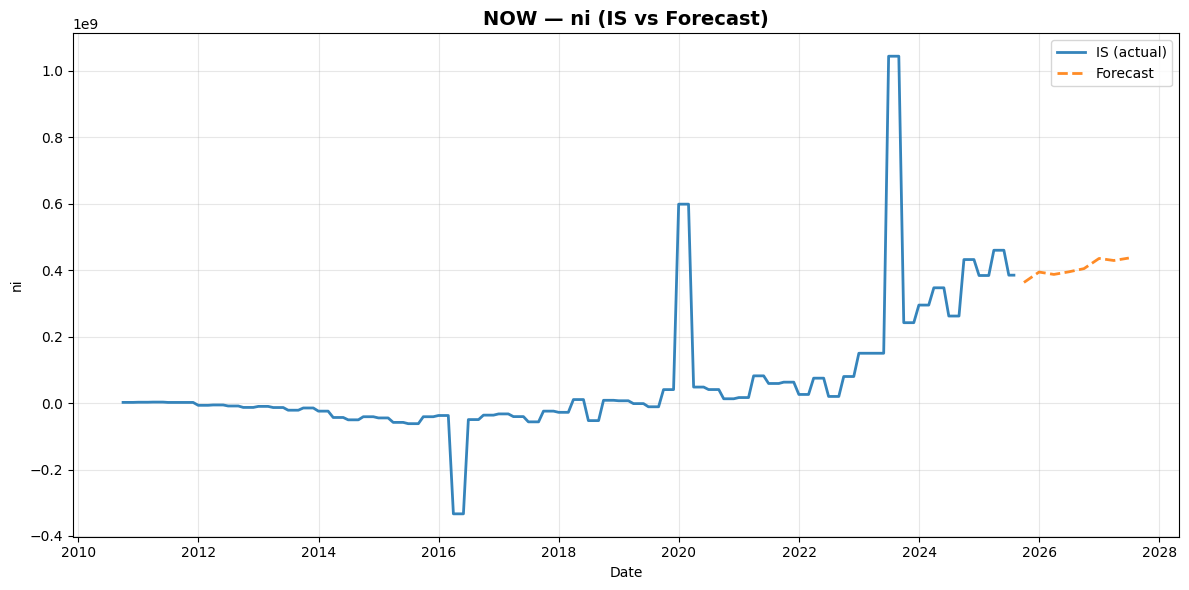

In [75]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sqlalchemy import create_engine, text

# =========================================
# 0) 사용자 입력
# =========================================
# └ 이전 스크립트에서 쓰던 접속 문자열을 그대로 재활용하거나,
#   아래 connection_string을 다시 지정하세요.
from typing import Optional

db_info = {
    "user": "stox7412",
    "password": "Apt106503!~",
    "host": "hystox74.synology.me",
    "port": "3307",
    "database": "investar",
}
connection_string = (
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
    f"@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

table_name = "us_financial_forecasts"   # 당신이 생성한 테이블명
target_ticker = "NOW"                   # 조회할 티커
value_col = "ni"                         # is_df에서 사용할 값 컬럼명 (= us_financial_forecasts.value_type)

# =========================================
# 1) 유틸 함수: 예측(저장) 데이터 로드
# =========================================

def load_forecast_timeseries(
    engine,
    table_name: str,
    ticker: str,
    value_type: str,
    created_date: Optional[str] = None,   # Python 3.9 호환
    use_latest_if_none: bool = True,
) -> pd.DataFrame:
    """
    us_financial_forecasts 테이블에서 특정 (ticker, value_type)의 시계열을 로드하여
    ['date','forecast_value','lower_ci','upper_ci','created_date'] 컬럼으로 반환.
    created_date를 지정하지 않으면 최신 created_date 스냅샷을 자동 선택(옵션).
    """
    with engine.connect() as conn:
        if created_date is None and use_latest_if_none:
            q_latest = text(f"""
                SELECT MAX(created_date) AS latest_created
                FROM {table_name}
                WHERE ticker = :ticker AND value_type = :value_type
            """)
            latest = conn.execute(q_latest, {"ticker": ticker, "value_type": value_type}).scalar()
            if latest is None:
                return pd.DataFrame(columns=["date","forecast_value","lower_ci","upper_ci","created_date"])
            created_date = latest

        q = text(f"""
            SELECT
                forecast_date AS date,
                forecast_value,
                lower_ci,
                upper_ci,
                created_date
            FROM {table_name}
            WHERE ticker = :ticker
              AND value_type = :value_type
              AND (:created_date IS NULL OR created_date = :created_date)
            ORDER BY forecast_date
        """)
        df = pd.read_sql(q, conn, params={
            "ticker": ticker,
            "value_type": value_type,
            "created_date": created_date
        })

    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"])
    for c in ["forecast_value","lower_ci","upper_ci"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)
    return df

# =========================================
# 2) is_df 준비 점검 및 필터링
# =========================================
if "is_df" not in globals():
    raise RuntimeError("❌ 'is_df' DataFrame이 메모리에 없습니다. 미리 로드해 주세요.")

need_cols = {"date","ticker", value_col}
missing = need_cols - set(is_df.columns)
if missing:
    raise RuntimeError(f"❌ is_df에 필요한 컬럼 누락: {missing}")

is_part = (is_df.loc[is_df["ticker"] == target_ticker, ["date", value_col]]
                .copy())
if is_part.empty:
    raise RuntimeError(f"❌ is_df에서 ticker='{target_ticker}' 데이터가 비었습니다.")

is_part["date"] = pd.to_datetime(is_part["date"])
is_part[value_col] = pd.to_numeric(is_part[value_col], errors="coerce")
is_part = (is_part.sort_values("date")
                  .drop_duplicates(subset=["date"])
                  .reset_index(drop=True))
is_part.rename(columns={value_col: "is_value"}, inplace=True)

# =========================================
# 3) DB 로드 + 결합
# =========================================
engine = create_engine(connection_string, pool_pre_ping=True)

fc_df = load_forecast_timeseries(
    engine=engine,
    table_name=table_name,
    ticker=target_ticker,
    value_type=value_col,        # 저장 시 value_type에 ni 등으로 저장했음
    created_date=None,           # 특정 스냅샷을 보고 싶으면 'YYYY-MM-DD HH:MM:SS' 로 지정
    use_latest_if_none=True      # None이면 최신 created_date를 자동 선택
)

engine.dispose()

# 결합 키는 date
merged = (pd.merge(is_part, fc_df, on="date", how="outer")
            .sort_values("date")
            .reset_index(drop=True))

# 양쪽 모두 NaN이면 제거
merged = merged[~(merged["is_value"].isna() & merged["forecast_value"].isna())].copy()

print(f"🔗 결합 완료: {len(merged)}행")
print(merged.head())

# =========================================
# 4) 시각화
# =========================================
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(f"{target_ticker} — {value_col} (IS vs Forecast)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel(value_col)

# IS 실측 시계열
is_series = merged[["date","is_value"]].dropna()
if not is_series.empty and np.isfinite(is_series["is_value"]).any():
    ax.plot(is_series["date"], is_series["is_value"], "-", linewidth=2, alpha=0.9, label="IS (actual)")

# Forecast 시계열
fc_series = merged[["date","forecast_value"]].dropna()
if not fc_series.empty and np.isfinite(fc_series["forecast_value"]).any():
    ax.plot(fc_series["date"], fc_series["forecast_value"], "--", linewidth=2, alpha=0.9, label="Forecast")

# 신뢰구간 음영 (있으면)
if {"lower_ci","upper_ci"}.issubset(merged.columns):
    ci = merged.dropna(subset=["lower_ci","upper_ci"])
    if not ci.empty and ci["lower_ci"].lt(ci["upper_ci"]).any():
        ax.fill_between(ci["date"], ci["lower_ci"], ci["upper_ci"], alpha=0.15, label="Forecast CI")

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================
# 5) 결과 DataFrame (필요 시 추가 분석)
# =========================================
# merged에는 다음 열이 포함됩니다:
# ['date', 'is_value', 'forecast_value', 'lower_ci', 'upper_ci', 'created_date']


In [76]:
merged.tail(12)

,date,is_value,forecast_value,lower_ci,upper_ci,created_date
175,2025-04-30,460000000.0,NaN,NaN,NaN,NaT
176,2025-05-31,460000000.0,NaN,NaN,NaN,NaT
177,2025-06-30,385000000.0,NaN,NaN,NaN,NaT
178,2025-07-31,385000000.0,NaN,NaN,NaN,NaT
179,2025-09-30,NaN,3.631567e+08,NaN,NaN,2025-08-20 15:31:10
180,2025-12-31,NaN,3.944073e+08,NaN,NaN,2025-08-20 15:31:10
181,2026-03-31,NaN,3.872455e+08,NaN,NaN,2025-08-20 15:31:10
182,2026-06-30,NaN,3.950519e+08,NaN,NaN,2025-08-20 15:31:10
183,2026-09-30,NaN,4.046815e+08,NaN,NaN,2025-08-20 15:31:10
184,2026-12-31,NaN,4.353623e+08,NaN,NaN,2025-08-20 15:31:10


In [63]:
# 데이터베이스 연결 설정 (필요에 따라 수정)
db_type = 'sqlite'  # 'sqlite', 'mysql', 'postgresql' 중 선택
db_file = 'us_financial_forecasts' # SQLite의 경우 파일 경로

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}



# ==============================
# 0) 사용자 설정
# ==============================
db_type = 'sqlite'   # 'sqlite' | 'mysql' | 'postgresql'
db_file = 'us_financial_forecasts'  # sqlite 파일명/경로
db_host = ''
db_port = '3307'
db_name = 'investar'
db_user = 's'
db_password = 'Apt106503!~'

# ✅ 여기를 실제로 사용할 ticker와 is_df의 값 컬럼명으로 바꾸세요
target_ticker = 'AAPL'          # 예: 'AAPL'
value_col = 'value'             # 예: is_df에 있는 값 컬럼명 (예: 'value', 'close', 'metric' 등)

# ✅ 실제 테이블/컬럼명으로 수정하세요
query = """
SELECT
    date_column AS date,
    value_column AS value
FROM your_table_name
WHERE date_column >= '2024-01-01'
ORDER BY date_column
"""

# ==============================
# 1) DB에서 데이터 로드 (date, value)
# ==============================
try:
    if db_type == 'sqlite':
        conn = sqlite3.connect(db_file)
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    elif db_type == 'mysql':
        import mysql.connector
        conn = mysql.connector.connect(
            host=db_host, port=db_port, database=db_name,
            user=db_user, password=db_password
        )
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    elif db_type == 'postgresql':
        import psycopg2
        conn = psycopg2.connect(
            host=db_host, port=db_port, database=db_name,
            user=db_user, password=db_password
        )
        db_df = pd.read_sql_query(query, conn)
        conn.close()
    else:
        raise ValueError("db_type은 'sqlite', 'mysql', 'postgresql' 중 하나여야 합니다.")

    print(f"✅ DB 데이터 로드 성공: {len(db_df)}행")
except Exception as e:
    raise RuntimeError(f"⚠️ DB 연결/쿼리 실패: {e}")

# 정리
db_df['date'] = pd.to_datetime(db_df['date'])
db_df = db_df.sort_values('date').reset_index(drop=True)
db_df = db_df[['date', 'value']]

# ==============================
# 2) is_df에서 target_ticker 데이터 준비
#    (is_df는 기존에 메모리에 있다고 가정)
# ==============================
# 안전 점검
if 'is_df' not in globals():
    raise RuntimeError("❌ 'is_df'가 메모리에 없습니다. is_df(DataFrame)를 미리 준비해 주세요.")

required_cols = {'date', 'ticker', value_col}
missing = required_cols - set(is_df.columns)
if missing:
    raise RuntimeError(f"❌ is_df에 필요한 컬럼이 없습니다: {missing}")

# 필터링 및 정리
is_sub = (
    is_df.loc[is_df['ticker'] == target_ticker, ['date', value_col]]
          .copy()
)
if is_sub.empty:
    raise RuntimeError(f"❌ is_df에서 ticker='{target_ticker}' 데이터가 비어 있습니다.")

is_sub['date'] = pd.to_datetime(is_sub['date'])
is_sub = is_sub.sort_values('date').reset_index(drop=True)
is_sub.rename(columns={value_col: 'is_value'}, inplace=True)

# ==============================
# 3) DB vs IS 결합 (date 기준 outer join)
# ==============================
merged = pd.merge(db_df, is_sub, on='date', how='outer').sort_values('date').reset_index(drop=True)

# 둘 다 NaN인 행은 제거 (시각화/통계 안정화)
merged = merged[~(merged['value'].isna() & merged['is_value'].isna())].copy()

print(f"🔗 결합 완료: {len(merged)}행")
print(merged.head())

# ==============================
# 4) 시각화 (line chart만)
# ==============================
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title(f"{target_ticker} — '{value_col}' (DB vs IS)", fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel(value_col)

# DB 시계열
db_series = merged[['date', 'value']].dropna()
if not db_series.empty and np.isfinite(db_series['value']).any():
    ax.plot(db_series['date'], db_series['value'], '-', label='DB (value)', linewidth=2, alpha=0.9)

# IS 시계열
is_series = merged[['date', 'is_value']].dropna()
if not is_series.empty and np.isfinite(is_series['is_value']).any():
    ax.plot(is_series['date'], is_series['is_value'], '--', label=f"IS ({value_col})", linewidth=2, alpha=0.9)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

⚠️ DB 연결/쿼리 실패: Execution failed on sql '
SELECT
    report_date  AS date,
    ni AS value
FROM us_financial_forecasts
WHERE report_date >= '2024-01-01'
ORDER BY report_date
': no such table: us_financial_forecasts
👉 SQLite 파일 내 테이블/컬럼 점검 결과:
🔎 SQLite Tables: []


DatabaseError: Execution failed on sql '
SELECT
    report_date  AS date,
    ni AS value
FROM us_financial_forecasts
WHERE report_date >= '2024-01-01'
ORDER BY report_date
': no such table: us_financial_forecasts

In [52]:
is_df

,date,report_date,ticker,period,sale,cogs,gp,xrd,xsga,idit,...,pir,txt,ni,nir,eps,epsdi,shrout,shroutdi,date_month,type
212,2021-09-30,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
213,2021-10-31,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
214,2021-11-30,2021-09-30,HAFN,Q3,1.897319e+08,195728362.0,-5996414.0,0.0,8940563.0,758811.0,...,-0.098143,1445546.0,-20758204.0,-0.109408,-0.0572,-0.0572,363157622.0,363157622.0,2021-09,historical
215,2021-12-31,2021-12-31,HAFN,Q4,2.416595e+08,229874292.0,11785255.0,0.0,10197010.0,958287.0,...,-0.024136,1793945.0,-7810686.0,-0.032321,-0.0215,-0.0215,363157622.0,363157622.0,2021-12,historical
216,2022-01-31,2021-12-31,HAFN,Q4,2.416595e+08,229874292.0,11785255.0,0.0,10197010.0,958287.0,...,-0.024136,1793945.0,-7810686.0,-0.032321,-0.0215,-0.0215,363157622.0,363157622.0,2021-12,historical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77178,2025-03-31,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77179,2025-04-30,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77180,2025-05-31,2025-03-28,FTV,Q1,1.474200e+09,593300000.0,880900000.0,105100000.0,542200000.0,0.0,...,0.136616,29500000.0,171900000.0,0.116606,0.5000,0.5000,341100000.0,344600000.0,2025-03,historical
77181,2025-06-30,2025-06-27,FTV,Q2,1.518800e+09,623100000.0,895700000.0,109200000.0,564300000.0,0.0,...,0.126416,25400000.0,166600000.0,0.109692,0.4900,0.4900,339600000.0,341700000.0,2025-06,historical
